### *Step 1 — Import Libraries*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# optional
plt.style.use('ggplot')

### *Step 2 — Load Dataset*

In [2]:
df = pd.read_csv("mobiles1.csv")

### *Step 3 — Basic Understanding*

In [4]:
df.head()

,battery,camera,display,memory,name,price,processor,rating,reviews,warranty
0,5000 mAh Battery,12MP + 2MP | 8MP Front Camera,15.8 cm (6.22 inch) HD+ Display,4 GB RAM | 64 GB ROM | Expandable Upto 512 GB,"Redmi 8 (Ruby Red, 64 GB)",9999,Qualcomm Snapdragon 439 Processor,4.4,"55,078 Reviews",Brand Warranty of 1 Year Available for Mobile ...
1,5000 mAh Battery,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 64 GB ROM,"Realme 5i (Aqua Blue, 64 GB)",10999,Qualcomm Snapdragon 665 2 GHz Processor,4.5,"20,062 Reviews",Sunrise Design
2,5000 mAh Battery,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 128 GB ROM,"Realme 5i (Aqua Blue, 128 GB)",11999,Qualcomm Snapdragon 665 (2 GHz) Processor,4.5,"20,062 Reviews",Sunrise Design
3,5000 mAh Battery,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 128 GB ROM,"Realme 5i (Forest Green, 128 GB)",11999,Qualcomm Snapdragon 665 (2 GHz) Processor,4.5,"20,062 Reviews",Sunrise Design
4,4000 mAh Battery,13MP + 2MP | 5MP Front Camera,15.49 cm (6.1 inch) HD+ Display,3 GB RAM | 32 GB ROM | Expandable Upto 256 GB,"Realme C2 (Diamond Blue, 32 GB)",7499,MediaTek P22 Octa Core 2.0 GHz Processor,4.4,"10,091 Reviews",Dual Nano SIM slots and Memory Card Slot


In [6]:
df.shape

(984, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   battery    984 non-null    object 
 1   camera     984 non-null    object 
 2   display    984 non-null    object 
 3   memory     984 non-null    object 
 4   name       984 non-null    object 
 5   price      984 non-null    int64  
 6   processor  983 non-null    object 
 7   rating     971 non-null    float64
 8   reviews    971 non-null    object 
 9   warranty   836 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 77.0+ KB


### *Step 4 — Null Value Handling*

In [8]:
df.isnull().sum()

battery        0
camera         0
display        0
memory         0
name           0
price          0
processor      1
rating        13
reviews       13
warranty     148
dtype: int64

In [10]:
df['reviews'] = df['reviews'].str.replace('Reviews', '')
df['reviews'] = df['reviews'].str.replace(',', '')
df['reviews'] = df['reviews'].str.strip()

df['reviews'] = pd.to_numeric(df['reviews'], errors='coerce')

In [11]:
df.head()

,battery,camera,display,memory,name,price,processor,rating,reviews,warranty
0,5000 mAh Battery,12MP + 2MP | 8MP Front Camera,15.8 cm (6.22 inch) HD+ Display,4 GB RAM | 64 GB ROM | Expandable Upto 512 GB,"Redmi 8 (Ruby Red, 64 GB)",9999,Qualcomm Snapdragon 439 Processor,4.4,55078.0,Brand Warranty of 1 Year Available for Mobile ...
1,5000 mAh Battery,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 64 GB ROM,"Realme 5i (Aqua Blue, 64 GB)",10999,Qualcomm Snapdragon 665 2 GHz Processor,4.5,20062.0,Sunrise Design
2,5000 mAh Battery,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 128 GB ROM,"Realme 5i (Aqua Blue, 128 GB)",11999,Qualcomm Snapdragon 665 (2 GHz) Processor,4.5,20062.0,Sunrise Design
3,5000 mAh Battery,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 128 GB ROM,"Realme 5i (Forest Green, 128 GB)",11999,Qualcomm Snapdragon 665 (2 GHz) Processor,4.5,20062.0,Sunrise Design
4,4000 mAh Battery,13MP + 2MP | 5MP Front Camera,15.49 cm (6.1 inch) HD+ Display,3 GB RAM | 32 GB ROM | Expandable Upto 256 GB,"Realme C2 (Diamond Blue, 32 GB)",7499,MediaTek P22 Octa Core 2.0 GHz Processor,4.4,10091.0,Dual Nano SIM slots and Memory Card Slot


In [13]:
df['rating'].fillna(df['rating'].median(), inplace=True)
df['reviews'].fillna(df['reviews'].median(), inplace=True)

C:\Users\KAIF FIROZ\AppData\Local\Temp\ipykernel_30680\1694098539.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(df['rating'].median(), inplace=True)
C:\Users\KAIF FIROZ\AppData\Local\Temp\ipykernel_30680\1694098539.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [14]:
df['processor'].fillna('Unknown', inplace=True)

C:\Users\KAIF FIROZ\AppData\Local\Temp\ipykernel_30680\2564564392.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['processor'].fillna('Unknown', inplace=True)


In [15]:
df.isnull().sum()

battery        0
camera         0
display        0
memory         0
name           0
price          0
processor      0
rating         0
reviews        0
warranty     148
dtype: int64

In [16]:
df['warranty'].fillna('Unknown', inplace=True)

C:\Users\KAIF FIROZ\AppData\Local\Temp\ipykernel_30680\276655464.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['warranty'].fillna('Unknown', inplace=True)


In [17]:
df.isnull().sum()

battery      0
camera       0
display      0
memory       0
name         0
price        0
processor    0
rating       0
reviews      0
warranty     0
dtype: int64

### *Step 6 — Statistical Summary*

In [28]:
df.describe()

,price,rating,reviews
count,984.000000,984.000000,984.000000
mean,15429.848577,4.241972,6364.517276
std,12891.355967,0.298379,14877.471820
min,887.000000,2.700000,0.000000
25%,7499.000000,4.100000,107.750000
50%,11649.000000,4.300000,648.000000
75%,17999.250000,4.400000,4318.000000
max,104999.000000,4.900000,153238.000000


### *Step 7 — Data Cleaning*

In [18]:
df['price'] = df['price'].replace('[₹,]', '', regex=True).astype(float)

df['reviews'] = df['reviews'].replace(',', '', regex=True)
df['reviews'] = pd.to_numeric(df['reviews'], errors='coerce')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   battery    984 non-null    object 
 1   camera     984 non-null    object 
 2   display    984 non-null    object 
 3   memory     984 non-null    object 
 4   name       984 non-null    object 
 5   price      984 non-null    float64
 6   processor  984 non-null    object 
 7   rating     984 non-null    float64
 8   reviews    984 non-null    float64
 9   warranty   984 non-null    object 
dtypes: float64(3), object(7)
memory usage: 77.0+ KB


### *Step 8 — Visualization 1 `Price Distribution`*


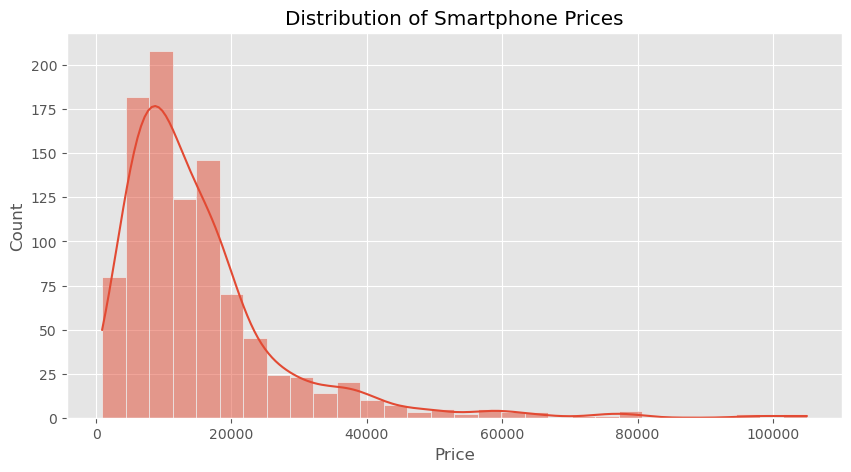

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=30, kde=True)

plt.title('Distribution of Smartphone Prices')
plt.xlabel('Price')
plt.ylabel('Count')

plt.show()

### *Step 8 — Visualization 2 `Rating vs Price`*

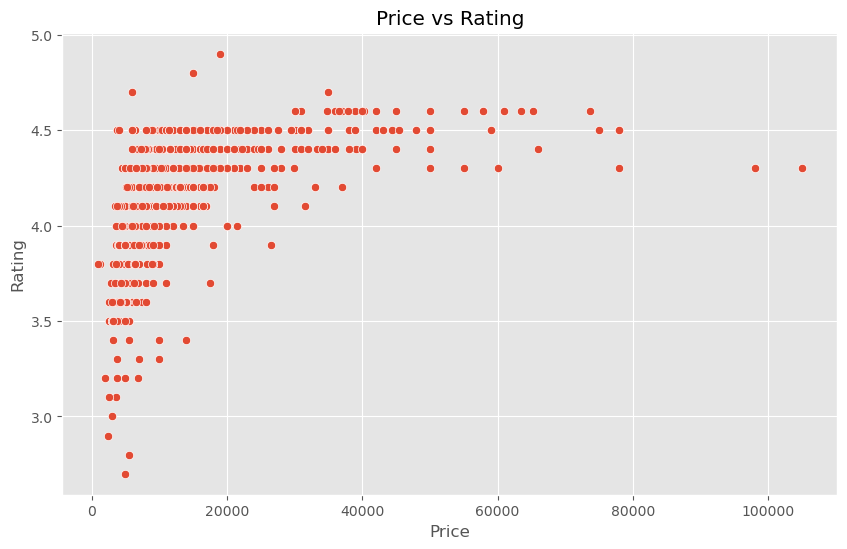

In [21]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='price', y='rating', data=df)

plt.title('Price vs Rating')
plt.xlabel('Price')
plt.ylabel('Rating')

plt.show()

### *Step 8 — Visualization 3 `Top 10 Most Expensive Phones`*

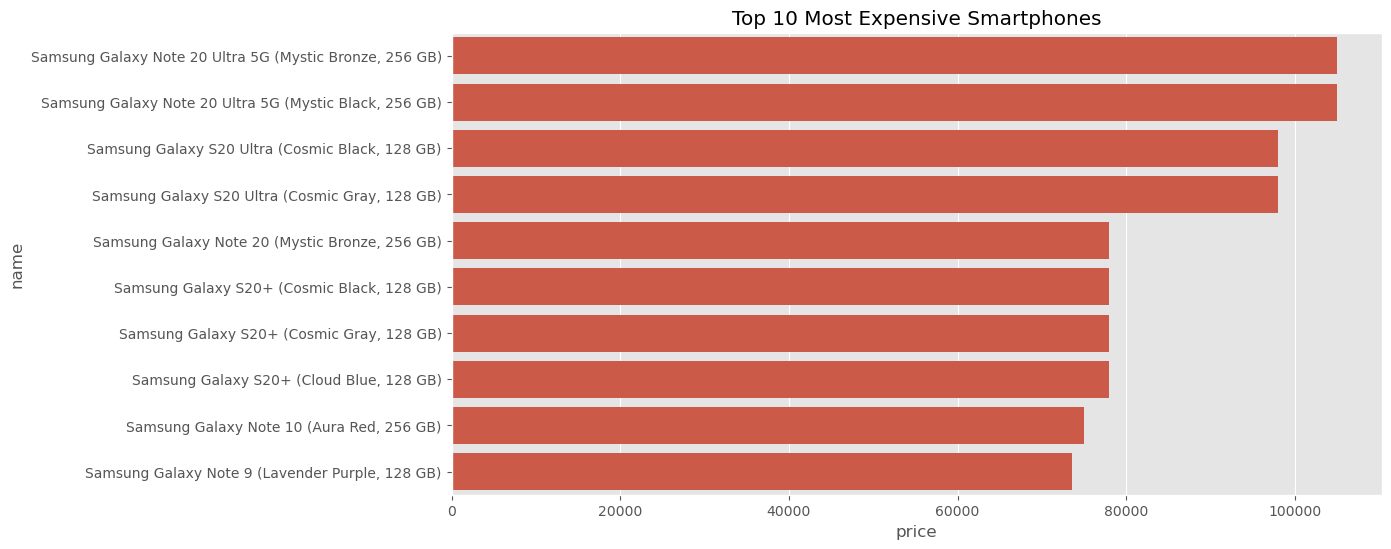

In [22]:
top10 = df.sort_values(by='price', ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(x='price', y='name', data=top10)

plt.title('Top 10 Most Expensive Smartphones')

plt.show()

### *Ratings are generally clustered between 4.0 and 4.5.*

In [27]:
df['rating'].groupby(df['rating']).sum()

rating
2.7       2.7
2.8       2.8
2.9       2.9
3.0       3.0
3.1       6.2
3.2      22.4
3.3       9.9
3.4      20.4
3.5      52.5
3.6      86.4
3.7      77.7
3.8     117.8
3.9     132.6
4.0     144.0
4.1     332.1
4.2     340.2
4.3     752.5
4.4    1073.6
4.5     841.5
4.6     119.6
4.7      18.8
4.8       9.6
4.9       4.9
Name: rating, dtype: float64

# Insights

1. Most smartphones fall within the budget and mid-range pricing segment.

2. Expensive smartphones do not always receive the highest ratings.

3. Certain brands dominate the premium smartphone category.

4. Ratings are generally clustered between 4.0 and 4.5.